# C1 – Week 1: Museum painting retrieval with 1D color histograms

## What we have to do
We have a **museum database (BBDD)** of 287 paintings and a set of **query photos** of some of those paintings.
For every query, the system must return the **K most similar museum paintings, ordered by similarity** (query-by-example retrieval).
This week the only allowed descriptor is a **1D histogram** (gray level, or per-channel color histograms concatenated).

| Task | What | Where |
|---|---|---|
| **1** | Compute image descriptors for BBDD and QSD1 (up to two methods) | §2 |
| **2** | Implement similarity measures (Euclidean, L1, χ², histogram intersection, Hellinger, …) | §3 |
| **3** | Retrieve the top-K for each QSD1 query and evaluate with **mAP@1** and **mAP@5** | §4 |
| — | Experiments: which color space / bins / measure / preprocessing works best, and why | §5 |
| — | Final two methods + good / bad cases | §6 |
| **4** | Predictions for the blind test set **QST1** (top-10 per query, `result.pkl`) | §7 |

**Datasets**
- `BBDD/`: museum images `bbdd_XXXXX.jpg` (id = number in the name).
- `qsd1_w1/`: 30 development queries + `gt_corresps.pkl` (correct BBDD id per query, e.g. `[[120], [170], ...]`).
- `qst1_w1/`: blind test queries (released Thursday Oct 1st, 12h). No ground truth: we submit, the teachers score.

**Deliverables (Sunday Oct 4th, 19:00)**: code, progress slides (problem, method, results, discussion) and
`TeamX/week1/QST1/method{1,2}/result.pkl` in the shared Drive.

**Pipeline**

`image → (preprocessing) → color space conversion → 1D histogram per channel → normalize → concatenate → distance to every BBDD descriptor → sort → top-K`

## 0. Setup

In [1]:
import pickle
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ---- Paths (relative to this notebook, which lives in Project/week1/) ----
DATA_DIR = Path(".")
BBDD_DIR = DATA_DIR / "BBDD"
QSD1_DIR = DATA_DIR / "qsd1_w1"
QST1_DIR = DATA_DIR / "qst1_w1"      # adjust the name if the released folder is called differently
RESULTS_DIR = DATA_DIR / "results"

# ---- Parameters ----
MAX_SIDE = 512     # images are downscaled for speed; normalized histograms barely change
K_SUBMIT = 10      # results per query in the QST1 submission

# ---- Plot style ----
plt.rcParams.update({
    "figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "axes.edgecolor": "#c3c2b7", "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8, "legend.frameon": False,
})
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]  # fixed categorical order
QUERY_COLOR, GT_COLOR = SERIES[0], SERIES[1]

## 1. Data

### 1.1 Load images and ground truth

In [3]:
def image_id(path: Path) -> int:
    # 'bbdd_00120.jpg' -> 120, '00007.jpg' -> 7
    return int(path.stem.split("_")[-1])


def load_image(path: Path, max_side: int = MAX_SIDE) -> np.ndarray:
    # Read as BGR (OpenCV convention) and downscale so the longest side is <= max_side
    img = cv2.imread(str(path))
    scale = max_side / max(img.shape[:2])
    if scale < 1:
        img = cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
    return img


def load_folder(folder: Path, pattern: str = "*.jpg"):
    paths = sorted(folder.glob(pattern), key=image_id)
    return [image_id(p) for p in paths], [load_image(p) for p in paths]


bbdd_ids, bbdd_imgs = load_folder(BBDD_DIR, "bbdd_*.jpg")
qsd1_ids, qsd1_imgs = load_folder(QSD1_DIR)
with open(QSD1_DIR / "gt_corresps.pkl", "rb") as f:
    qsd1_gt = pickle.load(f)

assert bbdd_ids == list(range(len(bbdd_ids)))   # row index == image id
print(f"BBDD: {len(bbdd_imgs)} images | QSD1: {len(qsd1_imgs)} queries | GT example: {qsd1_gt[:5]}")

BBDD: 287 images | QSD1: 30 queries | GT example: [[120], [170], [277], [227], [251]]


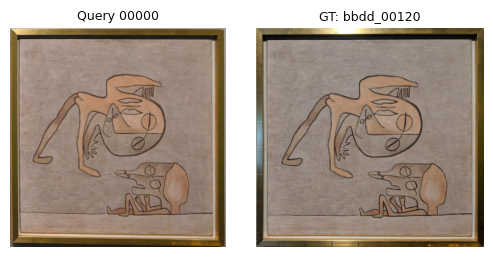

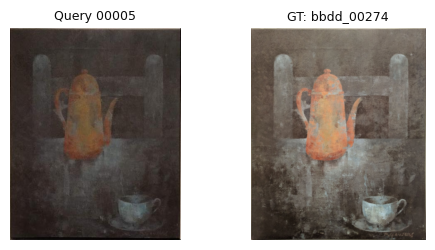

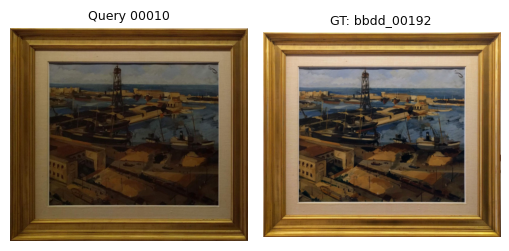

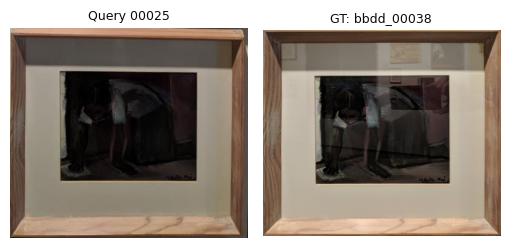

In [4]:
def rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def show_images(images, titles, size=2.6, title_colors=None):
    fig, axes = plt.subplots(1, len(images), figsize=(size * len(images), size))
    for i, (ax, img, t) in enumerate(zip(np.atleast_1d(axes), images, titles)):
        ax.imshow(rgb(img))
        ax.set_title(t, fontsize=9, color=(title_colors[i] if title_colors else "#0b0b0b"))
        ax.axis("off")
    plt.tight_layout()
    plt.show()


# Query / ground-truth pairs
for q in [0, 5, 10, 25]:
    show_images([qsd1_imgs[q], bbdd_imgs[qsd1_gt[q][0]]], [f"Query {q:05d}", f"GT: bbdd_{qsd1_gt[q][0]:05d}"])

### 1.2 What changes between a query and its museum image?
Before designing descriptors, look at *how* a query differs from its correct painting.
From the pairs above: framing is almost identical (the same frame and a bit of wall appear in both),
but **illumination** changes a lot: some queries are much darker or lighter, some have a warmer or cooler light.
Let's quantify it with the mean of each Lab channel (L = lightness, a/b = color).

Mean |query - GT| per channel:  L = 15.9   a = 1.2   b = 2.3
Queries darker than their GT: 17 / 30


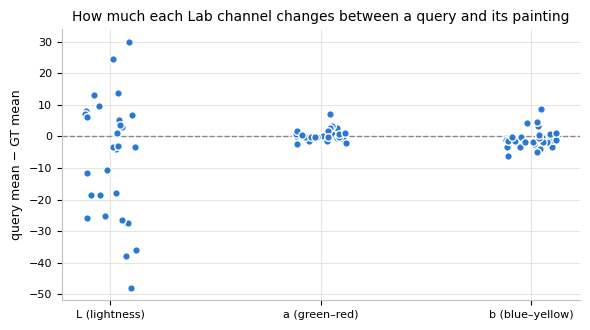

In [5]:
def mean_lab(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2LAB).reshape(-1, 3).mean(axis=0)


q_lab = np.array([mean_lab(img) for img in qsd1_imgs])
gt_lab = np.array([mean_lab(bbdd_imgs[g[0]]) for g in qsd1_gt])
diff = q_lab - gt_lab

print("Mean |query - GT| per channel:  L = %.1f   a = %.1f   b = %.1f" % tuple(np.abs(diff).mean(axis=0)))
print(f"Queries darker than their GT: {(diff[:, 0] < 0).sum()} / {len(diff)}")

fig, ax = plt.subplots(figsize=(6, 3.4))
jitter = np.random.default_rng(0).uniform(-0.12, 0.12, len(diff))
for ch, name in enumerate(["L (lightness)", "a (green–red)", "b (blue–yellow)"]):
    ax.scatter(ch + jitter, diff[:, ch], s=30, color=SERIES[0], edgecolor="white", linewidth=1, zorder=3)
ax.axhline(0, color="#898781", lw=1, ls="--")
ax.set_xticks(range(3), ["L (lightness)", "a (green–red)", "b (blue–yellow)"])
ax.set(ylabel="query mean − GT mean", title="How much each Lab channel changes between a query and its painting")
plt.tight_layout()
plt.show()

**Observation.** Each dot is one query. Lightness L changes a lot between a query and its painting (up to ±40,
in both directions: some queries are darker, some lighter), while the color channels a and b barely move.
A plain histogram of the brightness will therefore be unreliable → we will test (i) color spaces that separate
lightness from color, and (ii) **normalizing the illumination** before computing the histogram (§5.2).

## 2. Task 1 – Image descriptors: 1D color histograms

For each channel of the chosen color space we compute a **1D histogram** with `bins` bins, **normalize it to sum 1**
(so that images of different size are comparable – the counts become proportions) and **concatenate** the channels.
Joint 2D/3D histograms are not allowed this week.

In [6]:
# name -> (OpenCV conversion from BGR, channel names, value range of each channel)
COLOR_SPACES = {
    "GRAY":  (cv2.COLOR_BGR2GRAY,  ["Gray"],       [(0, 256)]),
    "RGB":   (cv2.COLOR_BGR2RGB,   ["R", "G", "B"], [(0, 256)] * 3),
    "HSV":   (cv2.COLOR_BGR2HSV,   ["H", "S", "V"], [(0, 180), (0, 256), (0, 256)]),   # OpenCV hue in [0, 180)
    "LAB":   (cv2.COLOR_BGR2LAB,   ["L", "a", "b"], [(0, 256)] * 3),
    "YCRCB": (cv2.COLOR_BGR2YCrCb, ["Y", "Cr", "Cb"], [(0, 256)] * 3),
    "RGCHROM": (None,              ["r", "g"],      [(0, 1), (0, 1)]),                 # r = R/(R+G+B), g = G/(R+G+B)
}


def convert(img_bgr, space):
    # Returns an H x W x C array in the requested color space
    conversion, _, _ = COLOR_SPACES[space]
    if space == "RGCHROM":   # normalized rgb (chromaticity): removes the overall intensity
        f = img_bgr.astype(np.float32)
        s = f.sum(axis=2) + 1e-6
        return np.dstack([f[..., 2] / s, f[..., 1] / s])
    out = cv2.cvtColor(img_bgr, conversion)
    return out[..., None] if out.ndim == 2 else out


def channel_histograms(img_bgr, space, bins):
    # List with one normalized 1D histogram per channel
    x = convert(img_bgr, space)
    _, _, ranges = COLOR_SPACES[space]
    hists = []
    for ch, (lo, hi) in enumerate(ranges):
        h = cv2.calcHist([np.ascontiguousarray(x[..., ch])], [0], None, [bins], [lo, hi]).ravel()
        hists.append(h / (h.sum() + 1e-10))
    return hists


def color_histogram(img_bgr, space="HSV", bins=16, weights=None):
    # Final descriptor: concatenation of the per-channel histograms (optionally weighted per channel)
    hists = channel_histograms(img_bgr, space, bins)
    if weights is not None:
        hists = [w * h for w, h in zip(weights, hists)]
    return np.concatenate(hists).astype(np.float32)

### 2.1 Visualizing the histograms (as in the task slides)
The image next to one histogram per channel. For the hue channel each bar is painted with the hue it represents,
which makes it easy to check that the histogram makes sense (e.g. an orange painting → peak in the orange hues).

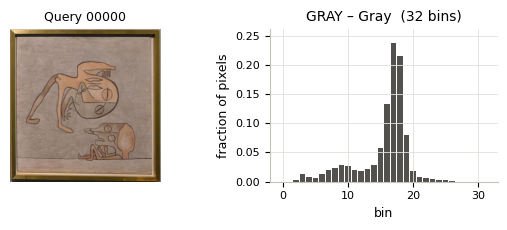

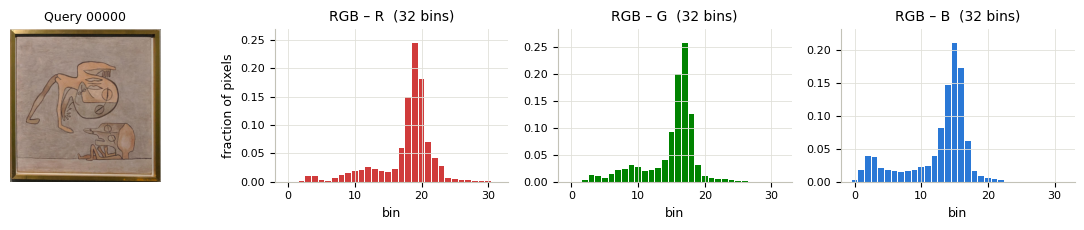

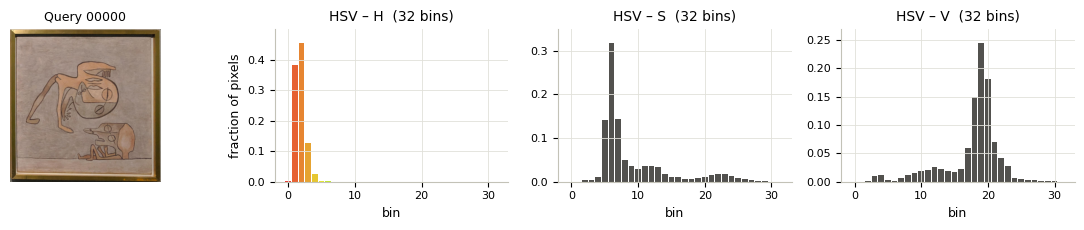

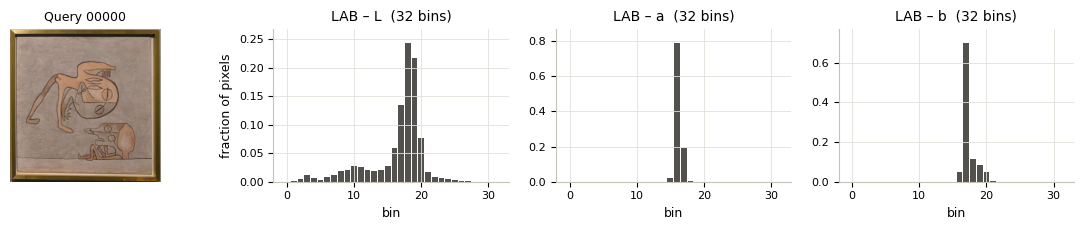

In [7]:
CHANNEL_COLORS = {"R": "#d03b3b", "G": "#008300", "B": "#2a78d6"}


def bar_colors(space, ch_name, bins):
    if ch_name == "H":   # paint each hue bin with its own hue
        hues = (np.arange(bins) + 0.5) * 180 / bins
        hsv = np.stack([hues, np.full(bins, 200), np.full(bins, 230)], axis=1).astype(np.uint8)[None]
        return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)[0] / 255
    return [CHANNEL_COLORS.get(ch_name, "#52514e")] * bins


def plot_histograms(img_bgr, space="HSV", bins=16, title=""):
    names = COLOR_SPACES[space][1]
    hists = channel_histograms(img_bgr, space, bins)
    fig, axes = plt.subplots(1, len(names) + 1, figsize=(2.9 * (len(names) + 1), 2.4),
                             gridspec_kw={"width_ratios": [1.2] + [1] * len(names)})
    axes[0].imshow(rgb(img_bgr)); axes[0].axis("off"); axes[0].set_title(title, fontsize=9)
    for ax, h, name in zip(axes[1:], hists, names):
        ax.bar(np.arange(bins), h, width=0.85, color=bar_colors(space, name, bins))
        ax.set_title(f"{space} – {name}  ({bins} bins)")
        ax.set_xlabel("bin"); ax.set_ylim(0, max(0.05, h.max() * 1.1))
    axes[1].set_ylabel("fraction of pixels")
    plt.tight_layout()
    plt.show()


q = 0
for space in ["GRAY", "RGB", "HSV", "LAB"]:
    plot_histograms(qsd1_imgs[q], space, bins=32, title=f"Query {q:05d}")

### 2.2 Query vs. its correct painting
If the descriptor is good, the histogram of a query should look like the histogram of its correct painting
(and different from other paintings). Here both are overlaid per channel.

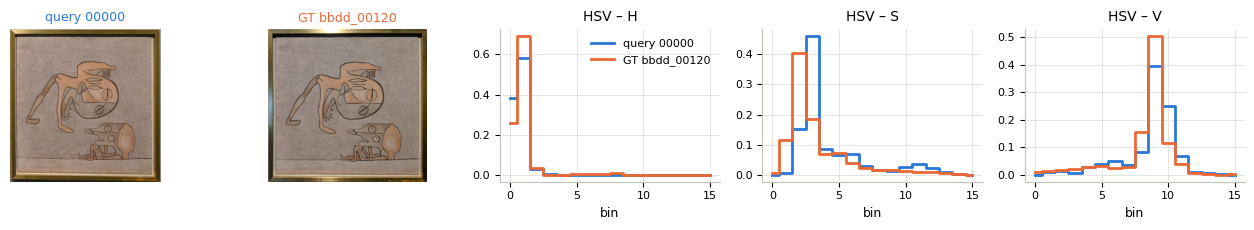

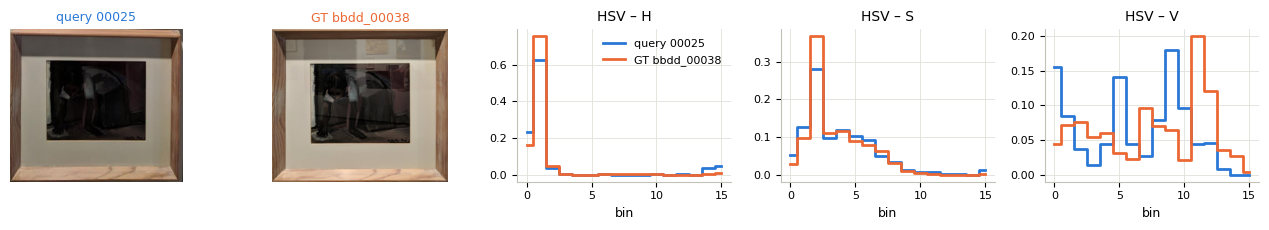

In [8]:
def compare_histograms(img_a, img_b, space="HSV", bins=16, labels=("query", "GT"), preprocess=None):
    if preprocess is not None:
        img_a, img_b = preprocess(img_a), preprocess(img_b)
    names = COLOR_SPACES[space][1]
    ha, hb = channel_histograms(img_a, space, bins), channel_histograms(img_b, space, bins)
    fig, axes = plt.subplots(1, len(names) + 2, figsize=(2.6 * (len(names) + 2), 2.4))
    for ax, img, lab, col in zip(axes[:2], [img_a, img_b], labels, [QUERY_COLOR, GT_COLOR]):
        ax.imshow(rgb(img)); ax.axis("off"); ax.set_title(lab, fontsize=9, color=col)
    for ax, a, b, name in zip(axes[2:], ha, hb, names):
        ax.step(np.arange(bins), a, where="mid", color=QUERY_COLOR, lw=2, label=labels[0])
        ax.step(np.arange(bins), b, where="mid", color=GT_COLOR, lw=2, label=labels[1])
        ax.set_title(f"{space} – {name}"); ax.set_xlabel("bin")
    axes[2].legend()
    plt.tight_layout()
    plt.show()


for q in [0, 25]:
    g = qsd1_gt[q][0]
    compare_histograms(qsd1_imgs[q], bbdd_imgs[g], "HSV", 16, labels=(f"query {q:05d}", f"GT bbdd_{g:05d}"))

Query 0 has similar lighting to its painting → the histograms almost overlap.
Query 25 is much darker → the V (brightness) histogram is shifted to the left and even the S channel changes:
this is exactly the kind of case a raw color histogram gets wrong.

## 3. Task 2 – Similarity measures

Every function compares one query descriptor `h` (length D) with all BBDD descriptors `H` (N × D) and returns N values.
To rank everything the same way, **all functions return a distance (lower = more similar)**; the similarities
(histogram intersection, Hellinger kernel, correlation) are negated.

| Measure | Formula (per descriptor) | Idea |
|---|---|---|
| Euclidean | $\sqrt{\sum (h_i - H_i)^2}$ | dominated by the largest bins |
| L1 | $\sum \lvert h_i - H_i\rvert$ | all bins count linearly |
| χ² | $\sum \frac{(h_i - H_i)^2}{h_i + H_i}$ | differences in small bins weigh more |
| Histogram intersection | $\sum \min(h_i, H_i)$ (similarity) | overlap between histograms; with normalized histograms it ranks exactly like L1 |
| Hellinger kernel | $\sum \sqrt{h_i H_i}$ (similarity) | compares square roots → less dominated by big bins |
| Jensen–Shannon | $\mathrm{KL}(h\Vert m) + \mathrm{KL}(H\Vert m)$, $m = \frac{h+H}{2}$ | symmetric distance between probability distributions |
| Correlation | Pearson correlation (similarity) | shape similarity (OpenCV `HISTCMP_CORREL`) |

In [9]:
EPS = 1e-10


def euclidean(h, H):
    return np.sqrt(np.sum((H - h) ** 2, axis=1))


def l1(h, H):
    return np.sum(np.abs(H - h), axis=1)


def chi2(h, H):
    return np.sum((H - h) ** 2 / (H + h + EPS), axis=1)


def histogram_intersection(h, H):      # similarity -> negated
    return -np.sum(np.minimum(H, h), axis=1)


def hellinger(h, H):                   # Hellinger kernel (similarity) -> negated
    return -np.sum(np.sqrt(H * h), axis=1)


def jensen_shannon(h, H):
    M = (H + h) / 2
    return np.sum(h * np.log((h + EPS) / (M + EPS)), axis=1) + np.sum(H * np.log((H + EPS) / (M + EPS)), axis=1)


def correlation(h, H):                 # similarity -> negated
    hc, Hc = h - h.mean(), H - H.mean(axis=1, keepdims=True)
    return -(Hc @ hc) / (np.linalg.norm(Hc, axis=1) * np.linalg.norm(hc) + EPS)


MEASURES = {
    "euclidean": euclidean, "l1": l1, "chi2": chi2, "intersection": histogram_intersection,
    "hellinger": hellinger, "jensen_shannon": jensen_shannon, "correlation": correlation,
}

In [10]:
# Sanity check: a histogram is at distance 0 (or maximal similarity) from itself, and the ranking works
h = color_histogram(qsd1_imgs[0], "HSV", 16)
H = np.stack([h, color_histogram(bbdd_imgs[5], "HSV", 16)])
pd.DataFrame({name: fn(h, H) for name, fn in MEASURES.items()}, index=["same image", "other image"]).round(3)

,euclidean,l1,chi2,intersection,hellinger,jensen_shannon,correlation
same image,0.000,0.000,0.000,-3.000,-3.000,0.000,-1.000
other image,0.747,2.446,1.408,-1.777,-2.556,0.803,-0.697


## 4. Task 3 – Retrieval and evaluation

**Retrieval**: for each query, compute the distance to all 287 BBDD descriptors, sort ascending, keep the first K ids.

**mAP@K**: for each query, AP@K rewards finding the correct painting as high as possible in the top K;
mAP@K is the mean over queries. With one correct painting per query: AP@K = 1/rank if rank ≤ K, else 0.
So **mAP@1** = fraction of queries whose first result is correct; **mAP@5** also gives partial credit to ranks 2–5.
We also report **top-10** (fraction of queries whose correct painting is in the 10 results we submit).
Implementation of `apk`/`mapk` from [benhamner/Metrics](https://github.com/benhamner/Metrics).

In [11]:
def retrieve(query_desc, db_desc, measure, k=10):
    # Top-k BBDD ids for each query -> list of lists (the submission format)
    return [np.argsort(measure(q, db_desc), kind="stable")[:k].tolist() for q in query_desc]


def apk(actual, predicted, k=10):
    # Average precision at k (benhamner/Metrics)
    predicted = predicted[:k]
    score, num_hits = 0.0, 0.0
    for i, p in enumerate(predicted):
        if p in actual and p not in predicted[:i]:
            num_hits += 1.0
            score += num_hits / (i + 1.0)
    return score / min(len(actual), k) if actual else 0.0


def mapk(actual, predicted, k=10):
    return float(np.mean([apk(a, p, k) for a, p in zip(actual, predicted)]))


def gt_ranks(query_desc, db_desc, measure, gt):
    # Position (1 = first) of the correct painting in the full ranking of each query
    return np.array([int(np.where(np.argsort(measure(q, db_desc), kind="stable") == g[0])[0][0]) + 1
                     for q, g in zip(query_desc, gt)])

To run many experiments cleanly, a **configuration** describes a full method:
`{"preprocess": ..., "space": ..., "bins": ..., "weights": ...}` + a measure.
Descriptors are cached, so each configuration is computed only once.

In [12]:
PREPROCESSING = {"none": lambda img: img}   # more options are added in §5.2

_cache = {}


def descriptors(images, name, space, bins, preprocess="none", weights=None, crop=0.0):
    key = (name, space, bins, preprocess, None if weights is None else tuple(weights), crop)
    if key not in _cache:
        out = []
        for img in images:
            if crop > 0:   # remove a fraction of the image on every side
                h, w = img.shape[:2]
                img = img[int(h * crop): h - int(h * crop), int(w * crop): w - int(w * crop)]
            img = PREPROCESSING[preprocess](img)
            if "+" in space:   # concatenation of several color spaces, e.g. "HSV+LAB"
                out.append(np.concatenate([color_histogram(img, s, bins, None) for s in space.split("+")]))
            else:
                out.append(color_histogram(img, space, bins, weights))
        _cache[key] = np.stack(out)
    return _cache[key]


def evaluate(space, bins, measure, preprocess="none", weights=None, crop=0.0):
    db = descriptors(bbdd_imgs, "bbdd", space, bins, preprocess, weights, crop)
    qs = descriptors(qsd1_imgs, "qsd1", space, bins, preprocess, weights, crop)
    ranks = gt_ranks(qs, db, MEASURES[measure], qsd1_gt)
    return {"mAP@1": np.mean(ranks == 1), "mAP@5": np.mean(np.where(ranks <= 5, 1 / ranks, 0)),
            "top10": np.mean(ranks <= 10), "ranks": ranks}


# Check that the mAP computed from ranks matches the official apk/mapk implementation
db, qs = descriptors(bbdd_imgs, "bbdd", "HSV", 16), descriptors(qsd1_imgs, "qsd1", "HSV", 16)
preds = retrieve(qs, db, l1, k=5)
r = evaluate("HSV", 16, "l1")
print(f"Baseline HSV-16 + L1  ->  mAP@1 = {mapk(qsd1_gt, preds, 1):.3f} (check {r['mAP@1']:.3f}),"
      f"  mAP@5 = {mapk(qsd1_gt, preds, 5):.3f} (check {r['mAP@5']:.3f}),  top-10 = {r['top10']:.2f}")

Baseline HSV-16 + L1  ->  mAP@1 = 0.500 (check 0.500),  mAP@5 = 0.588 (check 0.588),  top-10 = 0.87


## 5. Experiments

Each experiment has: **why** we test it, the result, and the **conclusion**.
Important caveat: QSD1 has only 30 queries, so one query = 0.033 of mAP@1. Differences of 1–2 queries are noise;
we trust a change only if it is consistent across several settings (color spaces, bins, measures).

### 5.1 Color space × bins × measure (no preprocessing)
**Why**: these are the three basic design choices of Task 1–2. We test all combinations:
6 color spaces × 5 bin sizes × 7 measures = 210 configurations.

In [13]:
SPACES = ["GRAY", "RGB", "HSV", "LAB", "YCRCB", "RGCHROM"]
BINS = [8, 16, 32, 64, 128]

rows = []
for space in SPACES:
    for bins in BINS:
        for measure in MEASURES:
            r = evaluate(space, bins, measure)
            rows.append({"space": space, "bins": bins, "measure": measure, "mAP@1": r["mAP@1"], "mAP@5": r["mAP@5"]})
grid_raw = pd.DataFrame(rows)
grid_raw.sort_values(["mAP@5", "mAP@1"], ascending=False).head(8).round(3)

,space,bins,measure,mAP@1,mAP@5
191,RGCHROM,32,chi2,0.567,0.634
193,RGCHROM,32,hellinger,0.533,0.618
194,RGCHROM,32,jensen_shannon,0.533,0.612
200,RGCHROM,64,hellinger,0.500,0.597
127,LAB,64,l1,0.533,0.596
129,LAB,64,intersection,0.533,0.596
78,HSV,16,l1,0.500,0.588
80,HSV,16,intersection,0.500,0.588


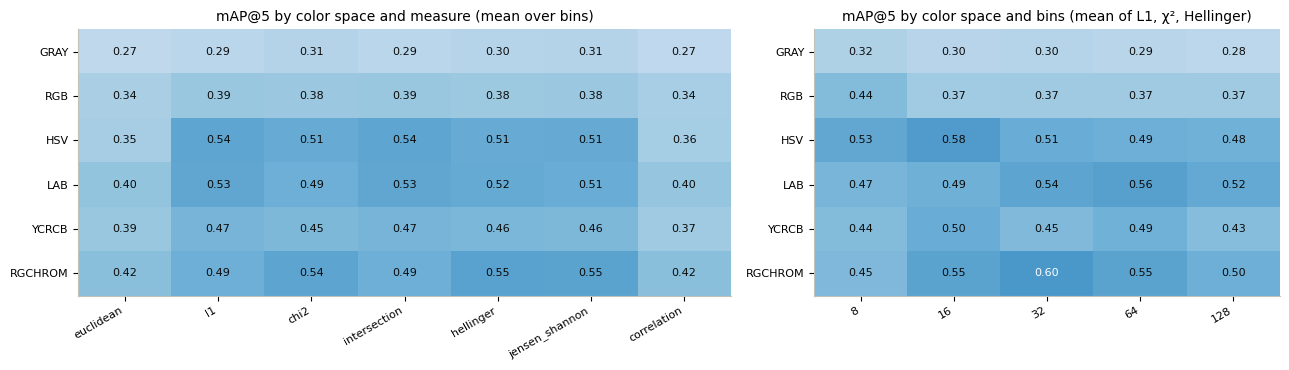

In [14]:
def heatmap(table, title, ax, fmt="{:.2f}", vmin=0, vmax=1):
    im = ax.imshow(table.values, cmap="Blues", vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(table.shape[1]), table.columns, rotation=30, ha="right")
    ax.set_yticks(range(table.shape[0]), table.index)
    ax.grid(False)
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            v = table.values[i, j]
            ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=8,
                    color="white" if v > vmin + 0.6 * (vmax - vmin) else "#0b0b0b")
    ax.set_title(title)
    return im


fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw={"width_ratios": [1.4, 1]})
t1 = grid_raw.pivot_table(index="space", columns="measure", values="mAP@5", aggfunc="mean").loc[SPACES, list(MEASURES)]
heatmap(t1, "mAP@5 by color space and measure (mean over bins)", axes[0])
t2 = grid_raw[grid_raw.measure.isin(["l1", "chi2", "hellinger"])].pivot_table(index="space", columns="bins", values="mAP@5")
heatmap(t2.loc[SPACES], "mAP@5 by color space and bins (mean of L1, χ², Hellinger)", axes[1])
plt.tight_layout()
plt.show()

**Conclusions 5.1**
- **Color matters**: gray level is by far the worst (~0.3). RGB is clearly worse than spaces that separate
  brightness from color (HSV, Lab, YCrCb, normalized rg), because in RGB the three channels all change when the light changes.
- **Measures**: Euclidean and correlation are consistently the worst. L1 / intersection / χ² / Hellinger / Jensen–Shannon are close
  (L1 and intersection give identical rankings, as expected for normalized histograms).
- **Bins**: too many bins hurt (a small illumination shift moves pixels to a neighbouring bin); 16–64 is the sweet spot.
- The best raw configurations plateau at **mAP@5 ≈ 0.55–0.63**. The limitation is not the measure, it is the illumination change (§1.2).

### 5.2 Illumination normalization (the key step)
**Why**: §1.2 showed that the main difference between a query and its painting is the lighting
(brightness and color of the light). If we cancel it *before* computing the histogram, histograms of the same painting
should align. We test pixel-wise corrections (range transforms, as in lecture L02):

| Name | What it does |
|---|---|
| `grayworld` | scales R, G, B so that they have the same mean → removes the **color cast** of the light (keeps brightness) |
| `channel_mean_128` | scales each of R, G, B so that its mean is 128 → removes the color cast **and** the exposure |
| `contrast_stretch` | per-channel linear stretch of the 1st–99th percentiles to [0, 255] (contrast mapping, L02) |

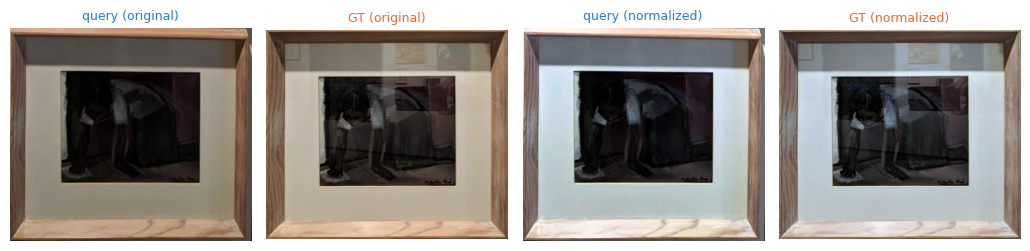

In [15]:
def grayworld(img):
    f = img.astype(np.float32)
    means = f.reshape(-1, 3).mean(axis=0)
    return np.clip(f * (means.mean() / (means + EPS)), 0, 255).astype(np.uint8)


def channel_mean_128(img, target=128):
    f = img.astype(np.float32)
    means = f.reshape(-1, 3).mean(axis=0)
    return np.clip(f * (target / (means + EPS)), 0, 255).astype(np.uint8)


def contrast_stretch(img, lo=1, hi=99):
    f = img.astype(np.float32)
    a, b = np.percentile(f.reshape(-1, 3), [lo, hi], axis=0)
    return np.clip((f - a) / (b - a + EPS) * 255, 0, 255).astype(np.uint8)


PREPROCESSING.update({"grayworld": grayworld, "channel_mean_128": channel_mean_128, "contrast_stretch": contrast_stretch})

# Visual effect on a dark query and its painting
q = 25
g = qsd1_gt[q][0]
show_images([qsd1_imgs[q], bbdd_imgs[g], channel_mean_128(qsd1_imgs[q]), channel_mean_128(bbdd_imgs[g])],
            ["query (original)", "GT (original)", "query (normalized)", "GT (normalized)"],
            title_colors=[QUERY_COLOR, GT_COLOR, QUERY_COLOR, GT_COLOR])

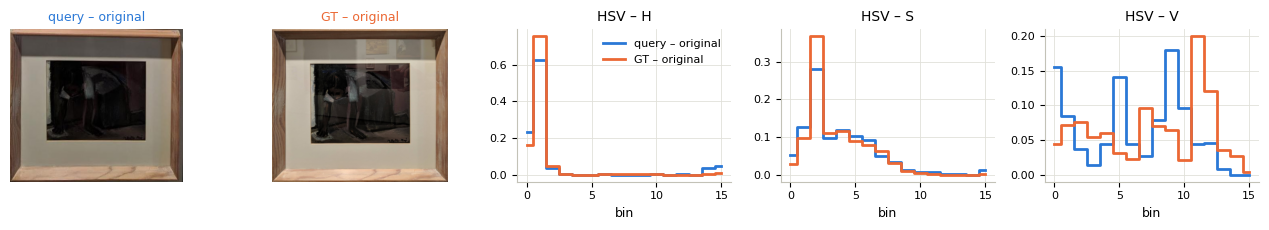

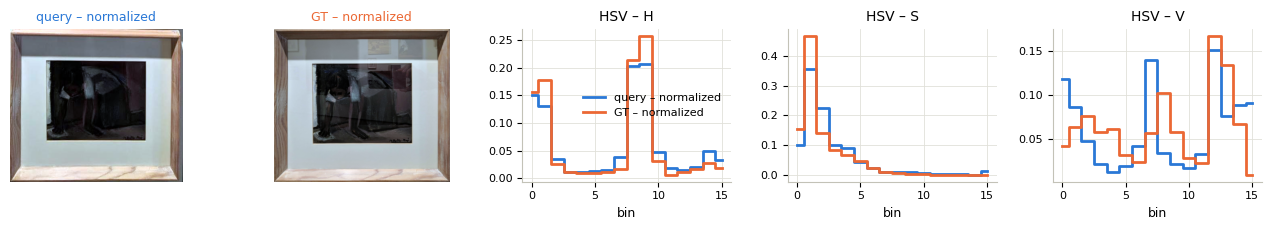

In [16]:
# Same query / GT pair, histograms before and after normalization
compare_histograms(qsd1_imgs[q], bbdd_imgs[g], "HSV", 16, labels=("query – original", "GT – original"))
compare_histograms(qsd1_imgs[q], bbdd_imgs[g], "HSV", 16, labels=("query – normalized", "GT – normalized"),
                   preprocess=channel_mean_128)

After normalization the H and S histograms of the query and its painting overlap almost perfectly and V is much closer.
Now the global numbers:

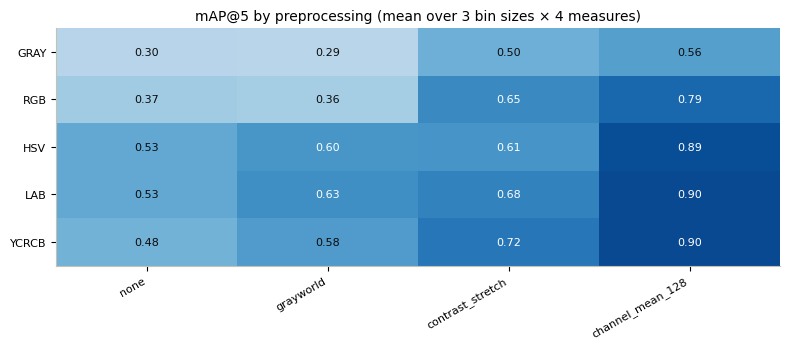

In [17]:
PRE_NAMES = ["none", "grayworld", "contrast_stretch", "channel_mean_128"]
rows = []
for pre in PRE_NAMES:
    for space in ["GRAY", "RGB", "HSV", "LAB", "YCRCB"]:
        for bins in [16, 32, 64]:
            for measure in ["l1", "chi2", "hellinger", "jensen_shannon"]:
                r = evaluate(space, bins, measure, preprocess=pre)
                rows.append({"preprocess": pre, "space": space, "bins": bins, "measure": measure,
                             "mAP@1": r["mAP@1"], "mAP@5": r["mAP@5"], "top10": r["top10"]})
grid_pre = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 3.6))
t = grid_pre.pivot_table(index="space", columns="preprocess", values="mAP@5").loc[["GRAY", "RGB", "HSV", "LAB", "YCRCB"], PRE_NAMES]
heatmap(t, "mAP@5 by preprocessing (mean over 3 bin sizes × 4 measures)", ax)
plt.tight_layout()
plt.show()

**Conclusions 5.2**
- `channel_mean_128` is a **huge** improvement: the average mAP@5 of HSV / Lab / YCrCb goes from ≈0.5 to ≈0.9,
  and the gain appears for *every* color space, bin size and measure → it is not luck on 30 queries.
- `grayworld` (color cast only) helps a little (+0.05–0.1): the color of the light is part of the problem, but not the main one.
- `contrast_stretch` helps more (+0.1–0.25), because it also fixes the exposure, but it is sensitive to extreme pixels
  (highlights, reflections).
- The **exposure** (overall brightness) is the biggest problem; a per-channel gain fixes exposure and color of the light at once.
- Why a gain per channel? A change of light roughly multiplies each channel by a constant (R·kR, G·kG, B·kB).
  Dividing each channel by its mean cancels those constants (the classic "diagonal / von Kries" illumination model).

In [18]:
# Robustness: the target value (128) is not a tuned magic number
for target in [100, 128, 160]:
    PREPROCESSING[f"mean_{target}"] = lambda img, t=target: channel_mean_128(img, t)
    vals = [evaluate(s, b, "chi2", preprocess=f"mean_{target}")["mAP@5"] for s, b in [("HSV", 16), ("LAB", 32), ("YCRCB", 32)]]
    print(f"target mean {target}:  mAP@5  HSV-16 = {vals[0]:.3f}   LAB-32 = {vals[1]:.3f}   YCRCB-32 = {vals[2]:.3f}")

target mean 100:  mAP@5  HSV-16 = 0.911   LAB-32 = 0.907   YCRCB-32 = 0.900


target mean 128:  mAP@5  HSV-16 = 0.950   LAB-32 = 0.906   YCRCB-32 = 0.925


target mean 160:  mAP@5  HSV-16 = 0.894   LAB-32 = 0.942   YCRCB-32 = 0.917


### 5.3 With normalization: which color space, bins and measure?
**Why**: the best settings may change once the illumination problem is solved, so we re-run the grid with `channel_mean_128`.

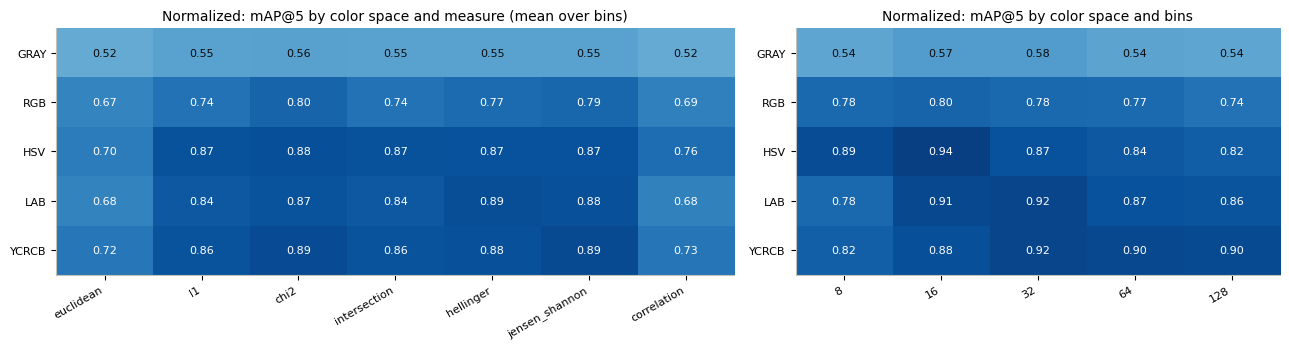

,space,bins,measure,mAP@1,mAP@5,top10
79,HSV,16,chi2,0.900,0.950,1.0
82,HSV,16,jensen_shannon,0.900,0.950,1.0
81,HSV,16,hellinger,0.867,0.933,1.0
78,HSV,16,l1,0.867,0.925,1.0
80,HSV,16,intersection,0.867,0.925,1.0
156,YCRCB,32,chi2,0.867,0.925,1.0
159,YCRCB,32,jensen_shannon,0.867,0.925,1.0
123,LAB,32,hellinger,0.900,0.922,1.0
124,LAB,32,jensen_shannon,0.900,0.919,1.0
72,HSV,8,chi2,0.867,0.919,1.0


In [19]:
rows = []
for space in ["GRAY", "RGB", "HSV", "LAB", "YCRCB"]:
    for bins in BINS:
        for measure in MEASURES:
            r = evaluate(space, bins, measure, preprocess="channel_mean_128")
            rows.append({"space": space, "bins": bins, "measure": measure,
                         "mAP@1": r["mAP@1"], "mAP@5": r["mAP@5"], "top10": r["top10"]})
grid_norm = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), gridspec_kw={"width_ratios": [1.4, 1]})
t1 = grid_norm.pivot_table(index="space", columns="measure", values="mAP@5").loc[["GRAY", "RGB", "HSV", "LAB", "YCRCB"], list(MEASURES)]
heatmap(t1, "Normalized: mAP@5 by color space and measure (mean over bins)", axes[0])
good = grid_norm[grid_norm.measure.isin(["l1", "chi2", "hellinger", "jensen_shannon"])]
t2 = good.pivot_table(index="space", columns="bins", values="mAP@5").loc[["GRAY", "RGB", "HSV", "LAB", "YCRCB"]]
heatmap(t2, "Normalized: mAP@5 by color space and bins", axes[1])
plt.tight_layout()
plt.show()

grid_norm.sort_values(["mAP@5", "mAP@1"], ascending=False).head(10).round(3)

**Conclusions 5.3**
- HSV, Lab and YCrCb are now all around 0.9; RGB and gray stay behind.
- **HSV works best with few bins (16)**, Lab and YCrCb with 32. More bins again hurt.
- χ², Hellinger and Jensen–Shannon are slightly better than L1; Euclidean and correlation remain the worst.
- Rather than taking the single highest cell (which can be luck), we choose settings that are good **and** whose
  neighbours (other bins / measures) are also good.

### 5.4 Is the lightness channel still harmful?
**Why**: before normalization, brightness was the unreliable part. After normalization, maybe it is useful again.
We multiply the lightness histogram (V in HSV, L in Lab, Y in YCrCb) by a weight before concatenating.

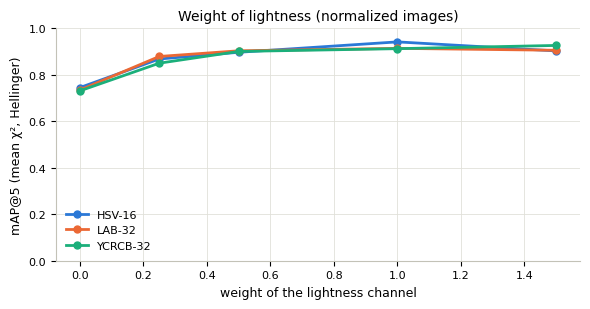

In [20]:
WEIGHTS = [0, 0.25, 0.5, 1.0, 1.5]
fig, ax = plt.subplots(figsize=(6, 3.2))
for i, (space, bins, idx) in enumerate([("HSV", 16, 2), ("LAB", 32, 0), ("YCRCB", 32, 0)]):
    vals = []
    for wl in WEIGHTS:
        w = [1.0, 1.0, 1.0]; w[idx] = wl
        vals.append(np.mean([evaluate(space, bins, m, "channel_mean_128", weights=w)["mAP@5"] for m in ["chi2", "hellinger"]]))
    ax.plot(WEIGHTS, vals, marker="o", ms=5, lw=2, color=SERIES[i], label=f"{space}-{bins}")
ax.set(xlabel="weight of the lightness channel", ylabel="mAP@5 (mean χ², Hellinger)", title="Weight of lightness (normalized images)", ylim=(0, 1))
ax.legend()
plt.tight_layout()
plt.show()

**Conclusion 5.4**: once the illumination is normalized, the lightness channel is **very informative**:
removing it (weight 0) drops mAP@5 from ≈0.92 to ≈0.74. Any weight ≥ 0.5 gives about the same result,
so we keep the simplest option: equal weights.

### 5.5 Does removing the frame help?
**Why**: frames (often golden or dark) are shared by many paintings, so they might confuse the retrieval.
We remove a fraction of the (normalized) image on each side and see what happens.

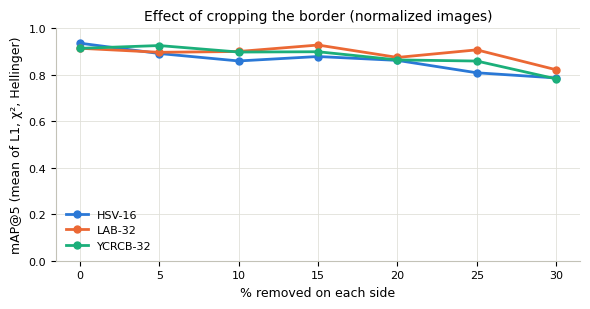

In [21]:
CROPS = [0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
fig, ax = plt.subplots(figsize=(6, 3.2))
for i, (space, bins) in enumerate([("HSV", 16), ("LAB", 32), ("YCRCB", 32)]):
    vals = [np.mean([evaluate(space, bins, m, "channel_mean_128", crop=c)["mAP@5"] for m in ["l1", "chi2", "hellinger"]])
            for c in CROPS]
    ax.plot([c * 100 for c in CROPS], vals, marker="o", ms=5, lw=2, color=SERIES[i], label=f"{space}-{bins}")
ax.set(xlabel="% removed on each side", ylabel="mAP@5 (mean of L1, χ², Hellinger)",
       title="Effect of cropping the border (normalized images)", ylim=(0, 1))
ax.legend()
plt.tight_layout()
plt.show()

**Conclusion 5.5**: cropping does **not** help: small crops change the result by ±1 query (noise) and large crops
(25–30%) clearly hurt. In this dataset the query and the museum photo show the *same* frame and wall, so the frame is
part of the "signature" of each photo rather than noise. We keep the full image.

### 5.6 Concatenating several color spaces
**Why**: each color space describes color differently; concatenating them (still 1D histograms) could add information.

In [22]:
rows = []
for space in ["HSV", "LAB", "YCRCB", "HSV+RGB", "HSV+LAB", "HSV+YCRCB", "HSV+LAB+YCRCB"]:
    for bins in [16, 32]:
        res = {m: evaluate(space, bins, m, "channel_mean_128")["mAP@5"] for m in ["l1", "chi2", "hellinger"]}
        rows.append({"descriptor": space, "bins": bins, **res, "mean": np.mean(list(res.values()))})
pd.DataFrame(rows).sort_values("mean", ascending=False).round(3)

,descriptor,bins,l1,chi2,hellinger,mean
8,HSV+LAB,16,0.928,0.967,0.967,0.954
10,HSV+YCRCB,16,0.925,0.950,0.967,0.947
9,HSV+LAB,32,0.942,0.942,0.950,0.944
12,HSV+LAB+YCRCB,16,0.928,0.950,0.950,0.943
0,HSV,16,0.925,0.950,0.933,0.936
13,HSV+LAB+YCRCB,32,0.923,0.942,0.940,0.935
7,HSV+RGB,32,0.919,0.925,0.942,0.929
11,HSV+YCRCB,32,0.894,0.933,0.944,0.924
3,LAB,32,0.915,0.906,0.922,0.914
5,YCRCB,32,0.917,0.925,0.900,0.914


**Conclusion 5.6**: the best concatenation (HSV+LAB) is only ≈0.02 mAP@5 above HSV alone, i.e. less than one query,
and adding RGB does not beat the best single space. The gain is within noise, so we keep single color spaces:
simpler and easier to explain.

## 6. Final methods

| | Preprocessing | Color space | Bins / channel | Measure | Why |
|---|---|---|---|---|---|
| **Method 1** | per-channel mean → 128 | HSV | 16 (48-D) | χ² | best overall; robust to the measure |
| **Method 2** | per-channel mean → 128 | CIELab | 32 (96-D) | Hellinger | perceptual space; different failure cases than method 1 |

Baseline for comparison: HSV, 16 bins, L1, no preprocessing.

In [23]:
METHODS = {
    "baseline": {"preprocess": "none",             "space": "HSV", "bins": 16, "measure": "l1"},
    "method1":  {"preprocess": "channel_mean_128", "space": "HSV", "bins": 16, "measure": "chi2"},
    "method2":  {"preprocess": "channel_mean_128", "space": "LAB", "bins": 32, "measure": "hellinger"},
}

rng = np.random.default_rng(0)
rows, ranks = [], {}
for name, cfg in METHODS.items():
    r = evaluate(cfg["space"], cfg["bins"], cfg["measure"], cfg["preprocess"])
    ranks[name] = r["ranks"]
    ap5 = np.where(r["ranks"] <= 5, 1 / r["ranks"], 0)
    boot = [ap5[rng.integers(0, len(ap5), len(ap5))].mean() for _ in range(2000)]   # bootstrap over queries
    rows.append({"method": name, "mAP@1": r["mAP@1"], "mAP@5": r["mAP@5"], "top10": r["top10"],
                 "mAP@5 95% CI": f"[{np.percentile(boot, 2.5):.2f}, {np.percentile(boot, 97.5):.2f}]"})
final = pd.DataFrame(rows).set_index("method")
final.round(3)

,mAP@1,mAP@5,top10,mAP@5 95% CI
method,,,,
baseline,0.5,0.588,0.867,"[0.43, 0.74]"
method1,0.9,0.950,1.000,"[0.90, 1.00]"
method2,0.9,0.922,1.000,"[0.82, 1.00]"


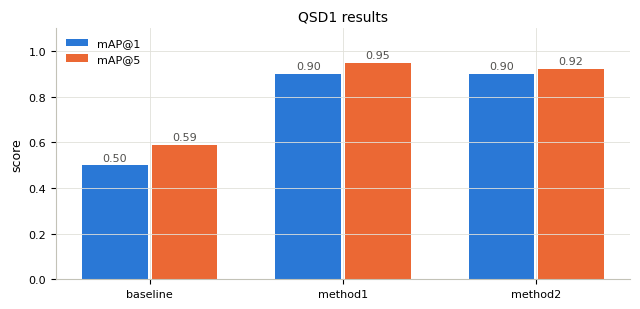

In [24]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
x = np.arange(len(final))
for i, metric in enumerate(["mAP@1", "mAP@5"]):
    bars = ax.bar(x + (i - 0.5) * 0.36, final[metric], width=0.34, color=SERIES[i], label=metric)
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.02, f"{b.get_height():.2f}", ha="center", fontsize=8, color="#52514e")
ax.set_xticks(x, final.index)
ax.set(ylim=(0, 1.1), ylabel="score", title="QSD1 results")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

The 95% confidence intervals (bootstrap over the 30 queries) of the baseline and of the final methods do not overlap:
the improvement is real, not noise.

### 6.1 Where does each query end up?
Position of the correct painting for every query (1 = perfect). Log scale because the baseline can put it very far.

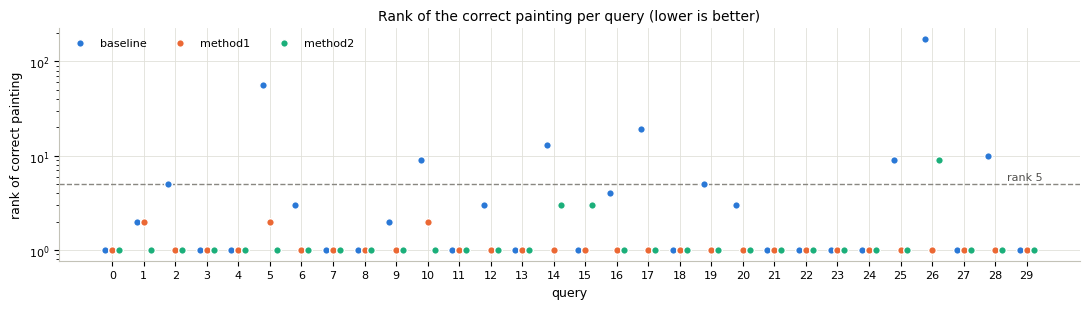

,1,2,5,6,9,10,12,14,15,16,17,19,20,25,26,28
baseline,2,5,56,3,2,9,3,13,1,4,19,5,3,9,173,10
method1,2,1,2,1,1,2,1,1,1,1,1,1,1,1,1,1
method2,1,1,1,1,1,1,1,3,3,1,1,1,1,1,9,1


In [25]:
fig, ax = plt.subplots(figsize=(11, 3.2))
qx = np.arange(len(qsd1_gt))
for i, name in enumerate(METHODS):
    ax.scatter(qx + (i - 1) * 0.22, ranks[name], s=30, color=SERIES[i], edgecolor="white", linewidth=1, label=name, zorder=3)
ax.set_yscale("log")
ax.axhline(5, color="#898781", lw=1, ls="--"); ax.text(len(qx) - 0.5, 5.5, "rank 5", fontsize=8, color="#52514e", ha="right")
ax.set(xticks=qx, xlabel="query", ylabel="rank of correct painting", title="Rank of the correct painting per query (lower is better)")
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

pd.DataFrame(ranks).T.loc[:, lambda d: (d != 1).any()]   # only queries where some method is not perfect

### 6.2 Qualitative results: good and bad cases
Top-5 for a query; the correct painting has a green title.

Fixed by the normalization (baseline rank > 5, method 1 rank = 1): [14, 17, 25, 26, 28]


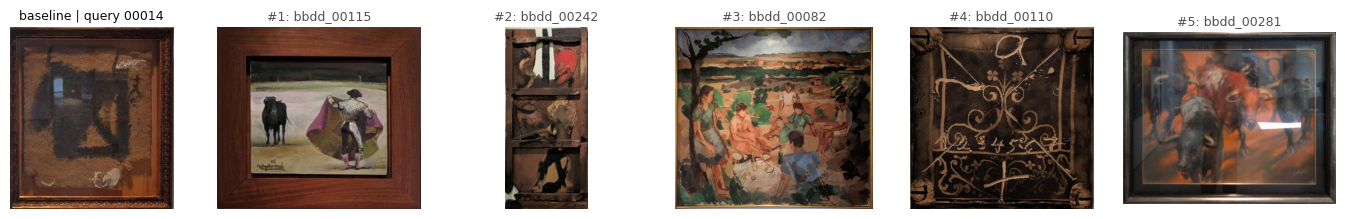

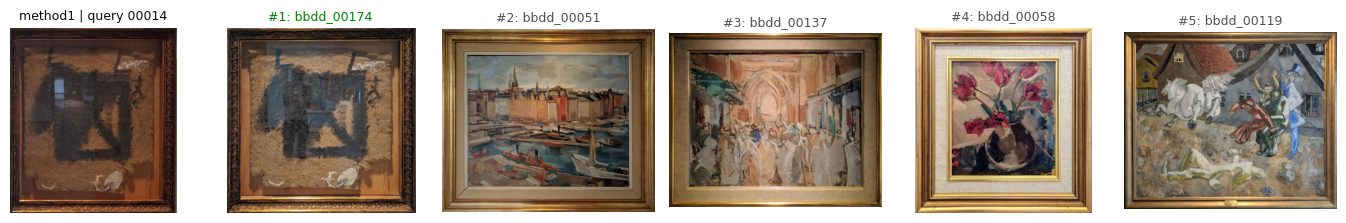

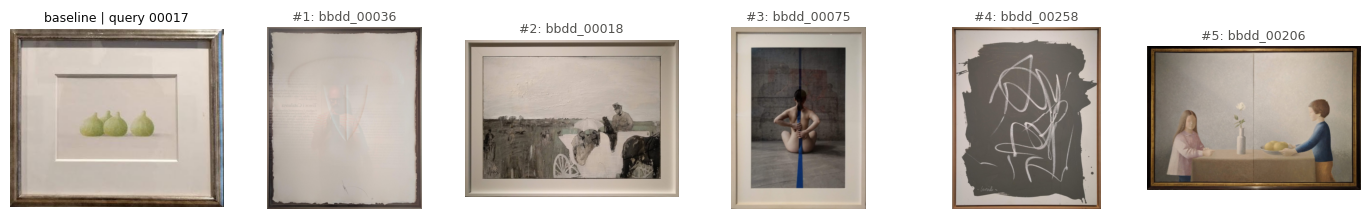

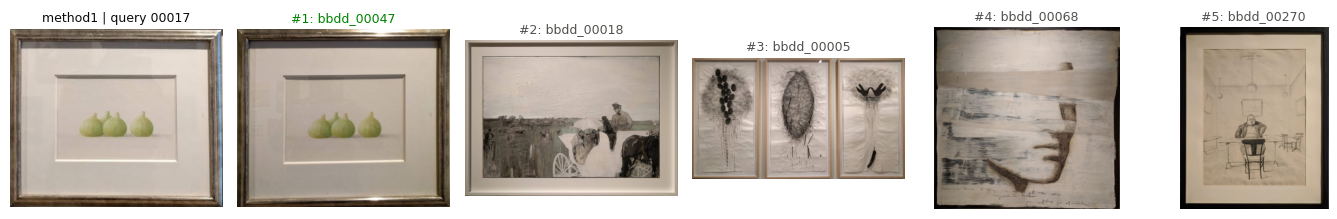

In [26]:
def show_retrieval(q, method, k=5, size=2.3):
    cfg = METHODS[method]
    db = descriptors(bbdd_imgs, "bbdd", cfg["space"], cfg["bins"], cfg["preprocess"])
    qs = descriptors(qsd1_imgs, "qsd1", cfg["space"], cfg["bins"], cfg["preprocess"])
    top = retrieve(qs[q:q + 1], db, MEASURES[cfg["measure"]], k)[0]
    imgs = [qsd1_imgs[q]] + [bbdd_imgs[i] for i in top]
    titles = [f"{method} | query {q:05d}"] + [f"#{r + 1}: bbdd_{i:05d}" for r, i in enumerate(top)]
    colors = ["#0b0b0b"] + ["#008300" if i in qsd1_gt[q] else "#52514e" for i in top]
    show_images(imgs, titles, size=size, title_colors=colors)


# Cases the baseline gets wrong and method 1 fixes
fixed = [q for q in range(len(qsd1_gt)) if ranks["baseline"][q] > 5 and ranks["method1"][q] == 1]
print("Fixed by the normalization (baseline rank > 5, method 1 rank = 1):", fixed)
for q in fixed[:2]:
    show_retrieval(q, "baseline")
    show_retrieval(q, "method1")

method1: queries not at rank 1 -> [(1, 2), (5, 2), (10, 2)]


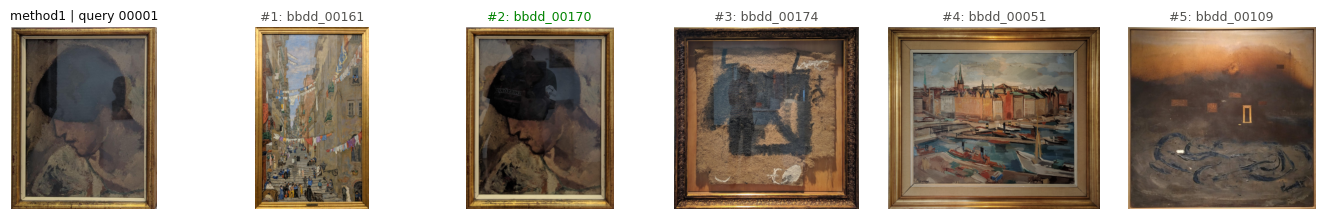

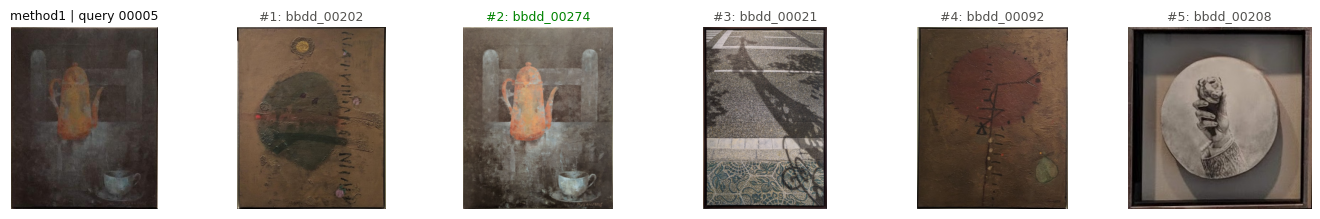

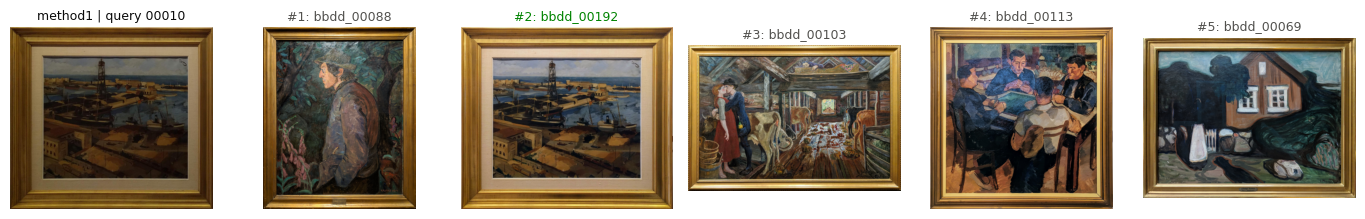

method2: queries not at rank 1 -> [(14, 3), (15, 3), (26, 9)]


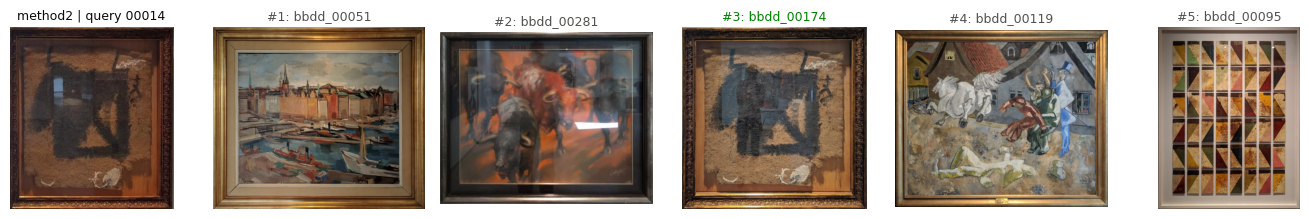

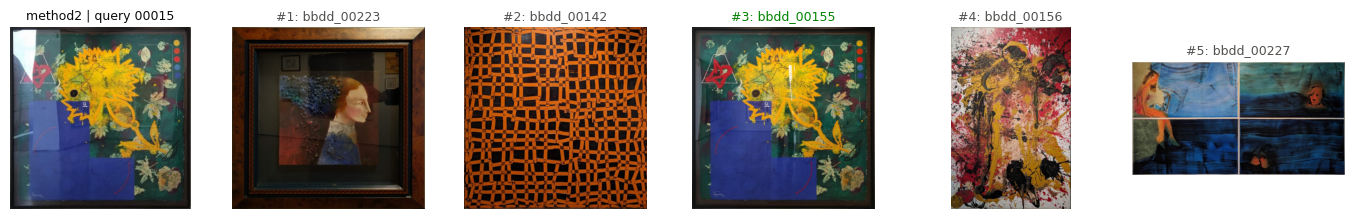

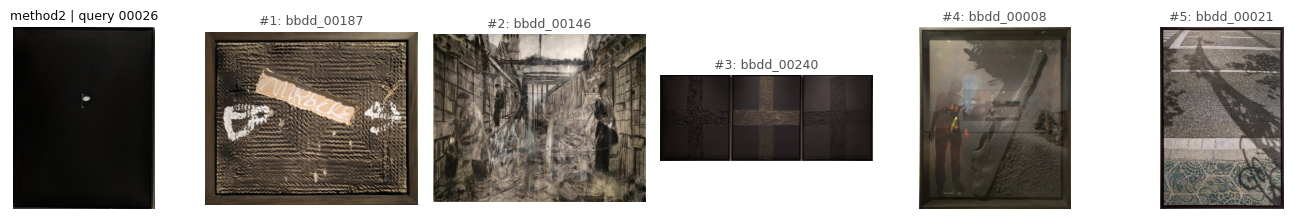

In [27]:
# Remaining errors of each final method
for method in ["method1", "method2"]:
    errors = [q for q in range(len(qsd1_gt)) if ranks[method][q] != 1]
    print(f"{method}: queries not at rank 1 -> {[(q, int(ranks[method][q])) for q in errors]}")
    for q in errors:
        show_retrieval(q, method)

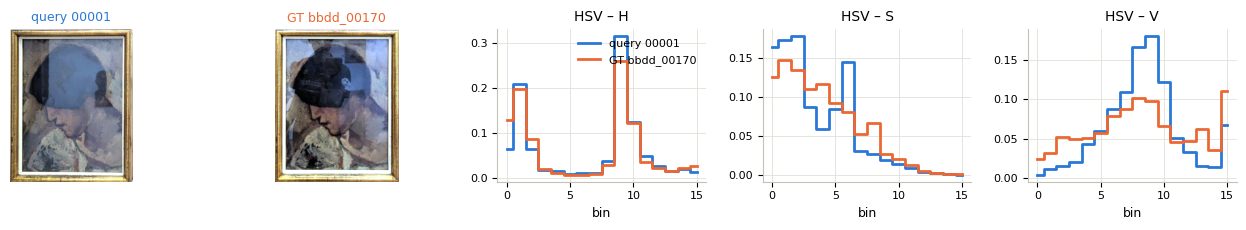

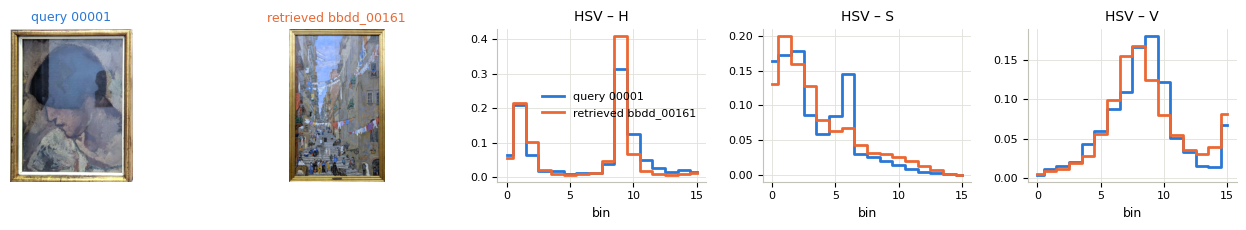

In [28]:
# Why does method 1 fail on its first error? Compare the query histogram with its GT and with the painting it chose instead
q = [q for q in range(len(qsd1_gt)) if ranks["method1"][q] != 1][0]
cfg = METHODS["method1"]
db = descriptors(bbdd_imgs, "bbdd", cfg["space"], cfg["bins"], cfg["preprocess"])
qs = descriptors(qsd1_imgs, "qsd1", cfg["space"], cfg["bins"], cfg["preprocess"])
wrong = retrieve(qs[q:q + 1], db, MEASURES[cfg["measure"]], 1)[0][0]
g = qsd1_gt[q][0]
pre = PREPROCESSING[cfg["preprocess"]]
compare_histograms(qsd1_imgs[q], bbdd_imgs[g], "HSV", 16, labels=(f"query {q:05d}", f"GT bbdd_{g:05d}"), preprocess=pre)
compare_histograms(qsd1_imgs[q], bbdd_imgs[wrong], "HSV", 16, labels=(f"query {q:05d}", f"retrieved bbdd_{wrong:05d}"), preprocess=pre)

**Discussion of the failures**: look at the two figures above. For the first error of method 1, the painting it
returns has a completely different content, yet its H, S and V histograms are almost identical to the query's
(sometimes even closer than the correct painting, e.g. when the query has a reflection on the glass).
A *global* histogram throws away *where* the colors are, so two different paintings with the same color distribution
are indistinguishable. The remaining errors are of this kind (similar palettes, dark low-saturation paintings,
reflections). This is the natural motivation for next week's **block (spatial) histograms**.

## 7. Task 4 – Predictions for the blind test set (QST1)

For each QST1 query: the top **K = 10** BBDD ids with each final method, saved as a list of lists
(`[[7, 2, ...], [76, 4, ...], ...]`, one list per query in file order) to
`results/QST1/method1/result.pkl` and `results/QST1/method2/result.pkl` → upload to `TeamX/week1/QST1/...`.

In [29]:
if not QST1_DIR.exists():
    print(f"'{QST1_DIR}' not found (QST1 is released on Thursday Oct 1st at 12h). Skipping.")
else:
    qst1_ids, qst1_imgs = load_folder(QST1_DIR)
    print(f"QST1: {len(qst1_imgs)} queries")
    for method in ["method1", "method2"]:
        cfg = METHODS[method]
        db = descriptors(bbdd_imgs, "bbdd", cfg["space"], cfg["bins"], cfg["preprocess"])
        qs = descriptors(qst1_imgs, "qst1", cfg["space"], cfg["bins"], cfg["preprocess"])
        preds = retrieve(qs, db, MEASURES[cfg["measure"]], k=K_SUBMIT)

        assert len(preds) == len(qst1_imgs) and all(len(p) == K_SUBMIT for p in preds)
        out = RESULTS_DIR / "QST1" / method / "result.pkl"
        out.parent.mkdir(parents=True, exist_ok=True)
        with open(out, "wb") as f:
            pickle.dump(preds, f)
        print(f"{method}: saved {out}  | first query -> {preds[0]}")

'qst1_w1' not found (QST1 is released on Thursday Oct 1st at 12h). Skipping.


## 8. Summary (for the slides)

- **Problem**: query photos differ from the museum images mainly in **illumination** (exposure and color of the light);
  framing is almost identical.
- **Descriptor**: per-channel 1D histograms, each normalized to sum 1, concatenated.
- **Findings on QSD1**
  - Color spaces separating brightness from color (HSV, Lab, YCrCb) ≫ RGB ≫ gray.
  - Euclidean and correlation are the worst measures; χ² / Hellinger / Jensen–Shannon / L1 are close.
  - 16–32 bins per channel; more bins hurt.
  - Cropping the frame does not help (the frame is part of the signature); large crops hurt.
  - **Normalizing each RGB channel to mean 128 before the histogram is the key step**:
    mAP@5 0.59 → 0.95 (method 1), robust across spaces, bins, measures and target value.
  - After normalization, the lightness channel becomes useful; concatenating color spaces adds nothing significant.
- **Limitation**: global histograms ignore spatial layout → different paintings with similar colors get confused
  (→ block histograms in week 2).